# 两层Relu前馈神经网络模拟任意函数练习

In [1]:
import tensorflow as tf
import numpy as np

# 定义要模拟的目标函数并采样好数据集

In [2]:
np.random.seed(42)

# ==================== 1. 定义目标函数 ====================
def target_func(x):
    return 0.5 * np.cos(2 * x) + 0.25 * np.sin(3 * x)

# ==================== 2. 生成数据集 ====================
# 定义域(-pi, 3pi)
x_min, x_max = -np.pi, np.pi

# 训练集：10000 个等间距点
n_train = 1000
x_train = np.linspace(x_min, x_max, n_train).reshape(-1, 1).astype(np.float32)
y_train = target_func(x_train).astype(np.float32)

# 测试集：300个随机点（重新采样）
n_test = 300
x_test = np.random.uniform(x_min, x_max, (n_test, 1)).astype(np.float32)
y_test = target_func(x_test).astype(np.float32)


# 使用numpy手写梯度计算

In [3]:
import numpy as np

class Matmul:
    def __init__(self):
        self.mem = {}
        
    def forward(self, x, W):
        h = np.matmul(x, W)
        self.mem={'x': x, 'W':W}
        return h
    


    def backward(self, grad_y):
        '''
        x: shape(N, d)
        w: shape(d, d')
        grad_y: shape(N, d')
        '''
        x = self.mem['x']
        W = self.mem['W']
        
        # 计算矩阵乘法的对应的梯度

        # grad_x = grad_y * W^T
        grad_x = np.matmul(grad_y, W.T)      

        # grad_W = x^T * grad_y
        grad_W = np.matmul(x.T, grad_y)       

        return grad_x, grad_W


class Relu:
    def __init__(self):
        self.mem = {}
        
    def forward(self, x):
        self.mem['x']=x
        return np.where(x > 0, x, np.zeros_like(x))
    
    def backward(self, grad_y):
        '''
        grad_y: same shape as x
        '''
        # 计算relu激活函数对应的梯度

        x = self.mem['x']
        grad_x = np.where(x > 0, grad_y, np.zeros_like(grad_y))
        return grad_x

# 建立模型

In [4]:
class myModel:
    def __init__(self):
        """
        定义模型参数
        """
        # 输入维度为1，隐藏层100，输出维度1
        # 加入偏置项：输入拼接一列1，因此W1的输入维度为2
        self.W1 = np.random.normal(size=[2, 200]) * 0.01  # 缩小初始化范围，利于收敛
        self.W2 = np.random.normal(size=[200, 1]) * 0.01  
        self.b2 = np.zeros((1, 1), dtype=np.float32)   # 可学习偏置
        
        self.mul_h1 = Matmul()
        self.mul_h2 = Matmul()
        self.relu = Relu()
        
    def forward(self, x):
        # x shape: (N, 1)
        N = x.shape[0]
        # 拼接偏置项：在最后一列加上全1
        bias = np.ones((N, 1))
        self.x_bias = np.concatenate([x, bias], axis=1)             # shape: (N, 2)
        
        # 第一层线性变换
        h1 = self.mul_h1.forward(self.x_bias, self.W1)              # shape: (N, 100)
        # ReLU激活
        h1_relu = self.relu.forward(h1)                             # shape: (N, 100)
        # 第二层线性变换
        y_pred = self.mul_h2.forward(h1_relu, self.W2) + self.b2    # shape: (N, 1)
        return y_pred
    
    def backward(self, grad_output):
        """
        grad_output: 损失对模型输出的梯度，shape (N, 1)
        返回：(grad_W1, grad_W2) 两个参数的梯度
        """
        # 第二层反向传播
        grad_h1_relu, grad_W2 = self.mul_h2.backward(grad_output)
        grad_b2 = np.sum(grad_output, axis=0, keepdims=True)   # shape (1,1)
        
        # ReLU反向传播
        grad_h1 = self.relu.backward(grad_h1_relu)
        
        # 第一层反向传播
        grad_x_bias, grad_W1 = self.mul_h1.backward(grad_h1)
        # grad_x_bias 是损失对输入 x_bias 的梯度，这里不需要用到
        
        return grad_W1, grad_W2, grad_b2
        
        
model = myModel()


# 计算 loss

In [5]:
def compute_loss(y_pred, y_true):
    """
    均方误差损失 (MSE)
    返回标量损失值
    """
    loss = np.mean((y_pred - y_true) ** 2)
    return loss


def train_one_step(model, x, y, lr=0.01):
    """
    单步训练：前向计算、反向传播、参数更新
    x, y: numpy数组，shape (N, 1)
    """
    # 前向传播
    y_pred = model.forward(x)
    
    # 计算损失
    loss = compute_loss(y_pred, y)
    
    # 计算损失对输出的梯度 (MSE的导数)
    N = x.shape[0]
    grad_output = 2 * (y_pred - y) / N   # 使用平均损失
    
    # 反向传播，得到参数梯度
    grad_W1, grad_W2, grad_b2 = model.backward(grad_output)
    
    # 更新参数（梯度下降）
    model.W1 -= lr * grad_W1
    model.W2 -= lr * grad_W2
    model.b2 -= lr * grad_b2
    
    return loss


def test(model, x, y):
    """
    在给定数据集上计算损失（用于评估）
    """
    y_pred = model.forward(x)
    loss = compute_loss(y_pred, y)
    return loss

# 开始训练

In [6]:
# 设置超参数
lr = 0.005
epochs = 5000           # 可以根据需要调整（见后面的说明）
batch_size = 32
loss_history = []

n_samples = x_train.shape[0]
n_batches = int(np.ceil(n_samples / batch_size))

for epoch in range(epochs):
    # 1. 打乱数据（提高随机性）
    indices = np.random.permutation(n_samples)
    x_shuffled = x_train[indices]
    y_shuffled = y_train[indices]

    epoch_loss = 0.0
    for i in range(n_batches):
        start = i * batch_size
        end = min(start + batch_size, n_samples)
        x_batch = x_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        # 在单个 batch 上执行一步训练，并返回该 batch 的平均损失
        loss = train_one_step(model, x_batch, y_batch, lr)

        # 加权累计损失（按 batch 实际样本数）
        epoch_loss += loss * (end - start)

    # 计算整个 epoch 的平均损失
    epoch_loss /= n_samples
    loss_history.append(epoch_loss)

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}, Training Loss: {epoch_loss:.6f}")

# 测试集评估（保持不变）
test_loss = test(model, x_test, y_test)
print(f"\nTest Loss: {test_loss:.6f}")

Epoch 500, Training Loss: 0.076810
Epoch 1000, Training Loss: 0.008160
Epoch 1500, Training Loss: 0.006344
Epoch 2000, Training Loss: 0.005130
Epoch 2500, Training Loss: 0.004798
Epoch 3000, Training Loss: 0.004570
Epoch 3500, Training Loss: 0.004510
Epoch 4000, Training Loss: 0.004456
Epoch 4500, Training Loss: 0.004435
Epoch 5000, Training Loss: 0.004405

Test Loss: 0.003694


# 画图可视化训练结果

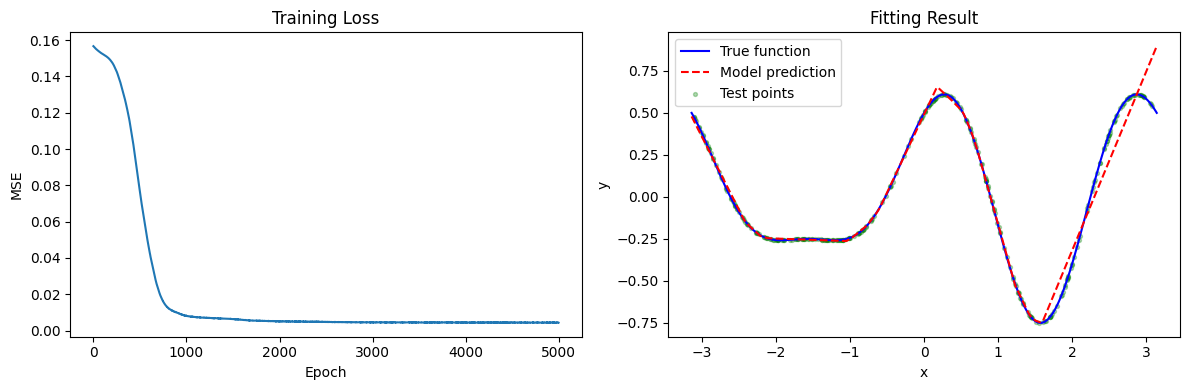

In [7]:
# （可选）绘制损失曲线和拟合效果
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.subplot(1,2,2)
# 生成密集点绘制真实函数和拟合曲线
x_dense = np.linspace(-np.pi, np.pi, 500).reshape(-1,1).astype(np.float32)
y_true_dense = target_func(x_dense)
y_pred_dense = model.forward(x_dense)
plt.plot(x_dense, y_true_dense, 'b-', label='True function')
plt.plot(x_dense, y_pred_dense, 'r--', label='Model prediction')
plt.scatter(x_test, y_test, c='g', s=8, alpha=0.3, label='Test points')
plt.legend()
plt.title("Fitting Result")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()